# Visualisation

In [28]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [13]:
df

,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,gas_lift_active,class
0,2017-05-05 21:00:00,448.580500,181.142100,118.200254,24.921658,78.569291,78.945323,0.0,1.0,0.0
1,2017-05-05 21:01:00,448.580500,181.142100,118.218223,24.921471,78.572018,78.346659,0.0,1.0,0.0
2,2017-05-05 21:02:00,448.580500,181.142100,118.226102,24.921245,78.575324,78.512230,0.0,1.0,0.0
3,2017-05-05 21:03:00,448.580500,181.142100,118.206880,24.921018,78.578630,78.810606,0.0,1.0,0.0
4,2017-05-05 21:04:00,448.580500,181.142100,118.225140,24.920792,78.581935,78.832500,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
609634,2018-05-19 18:57:00,335.816967,280.633420,3.212490,40.025221,39.083379,0.000000,0.0,0.0,108.0
609635,2018-05-19 18:58:00,335.829775,280.670470,3.226175,40.025203,39.057826,0.000000,0.0,0.0,108.0
609636,2018-05-19 18:59:00,335.844947,280.713222,3.236772,40.024951,39.118655,0.000000,0.0,0.0,108.0
609637,2018-05-19 19:00:00,335.857867,280.747078,3.247476,40.025164,38.852701,0.000000,0.0,0.0,108.0


<h1>30-Minute Temporal Trends per Day</h1>
By resampling the data to 30-minute intervals, we smooth out high-frequency noise and focus on the overall movement of temperatures and pressures across different days. The subplots below show the grouped sensors (Temp, Pressure, and Flow) for specific dates.

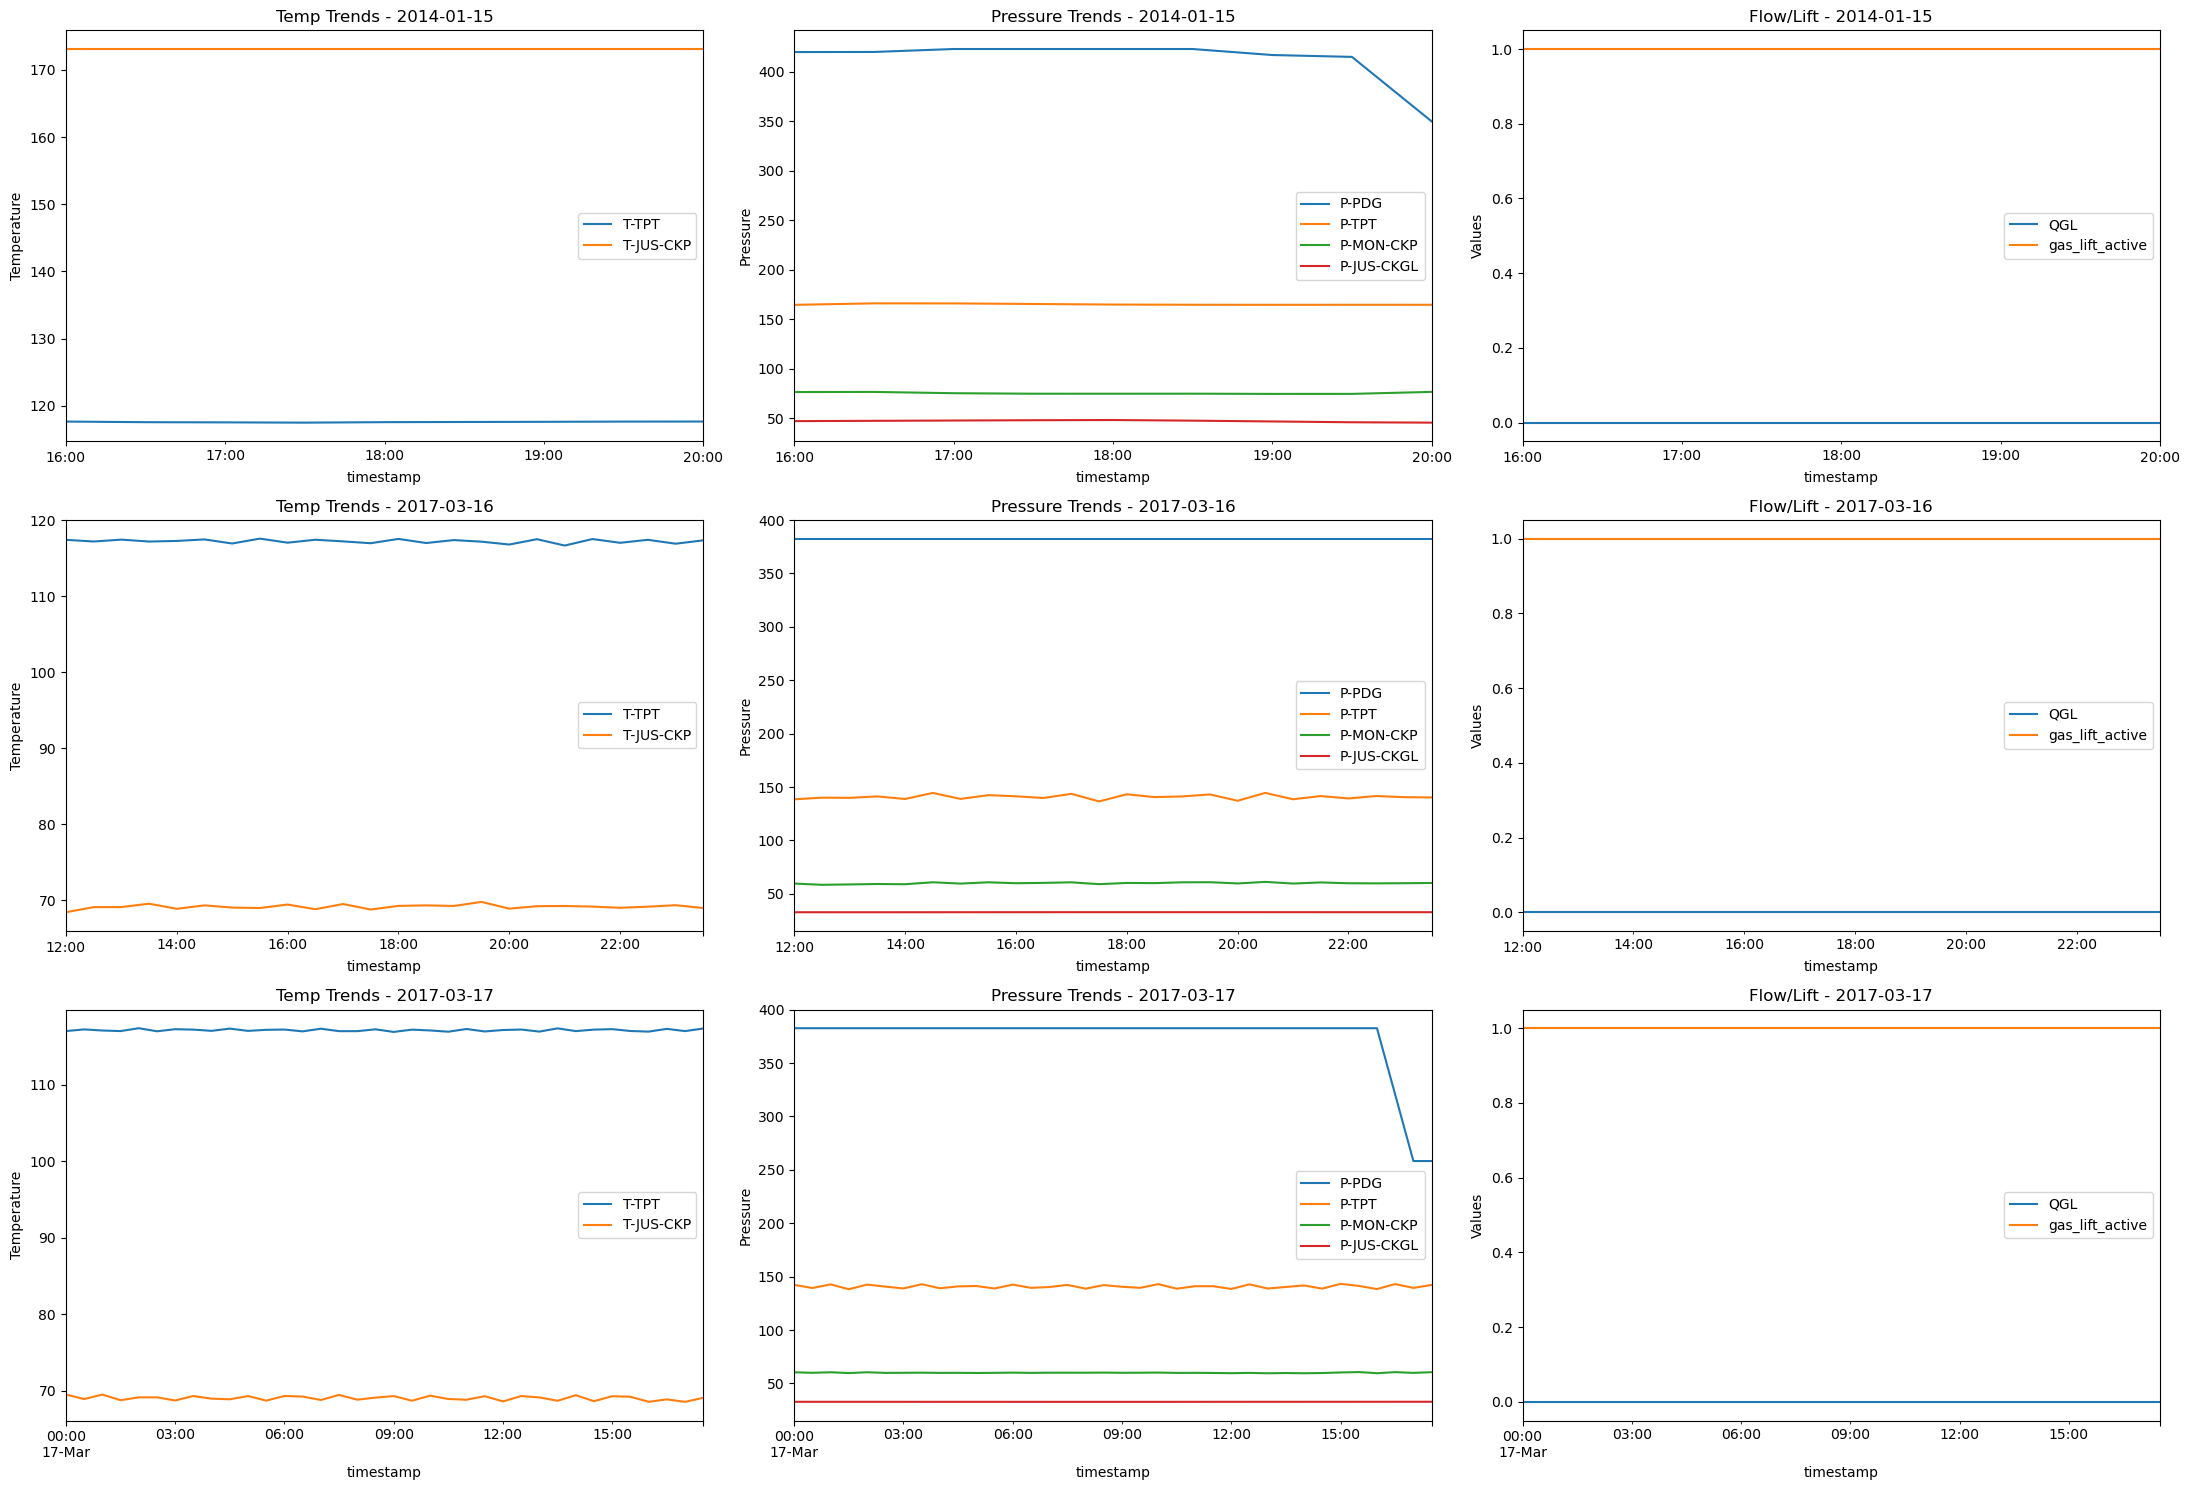

In [24]:
df = df.sort_values('timestamp')

# Column Groups
temp_cols = ['T-TPT', 'T-JUS-CKP']
press_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
flow_cols = ['QGL', 'gas_lift_active']

# Select sample dates for visualization
unique_dates = df['timestamp'].dt.date.unique()
sample_dates = unique_dates[:3]  # Example: first 3 unique days

fig, axes = plt.subplots(nrows=len(sample_dates), ncols=3, figsize=(22, 5 * len(sample_dates)))

for i, date in enumerate(sample_dates):
    day_data = df[df['timestamp'].dt.date == date]
    # Resample to 30-minute mean trend
    day_resampled = day_data.set_index('timestamp').resample('30min').mean()
    
    # Temperature Plot
    day_resampled[temp_cols].plot(ax=axes[i, 0], title=f"Temp Trends - {date}")
    axes[i, 0].set_ylabel("Temperature")
    
    # Pressure Plot
    day_resampled[press_cols].plot(ax=axes[i, 1], title=f"Pressure Trends - {date}")
    axes[i, 1].set_ylabel("Pressure")
    
    # Flow/Lift Plot
    day_resampled[flow_cols].plot(ax=axes[i, 2], title=f"Flow/Lift - {date}")
    axes[i, 2].set_ylabel("Values")

plt.tight_layout()
plt.show()

<h1>2. Clustering and Class Distribution (Scatter & KDE)</h1>
The scatter plots help us see how different fault classes occupy specific "regions" in the sensor space. The KDE plots are specifically designed to show the transition: we plot the Normal state (0), the Transient state (e.g., 101), and the Fault state (e.g., 1) together to see how the distribution shifts as the fault develops.

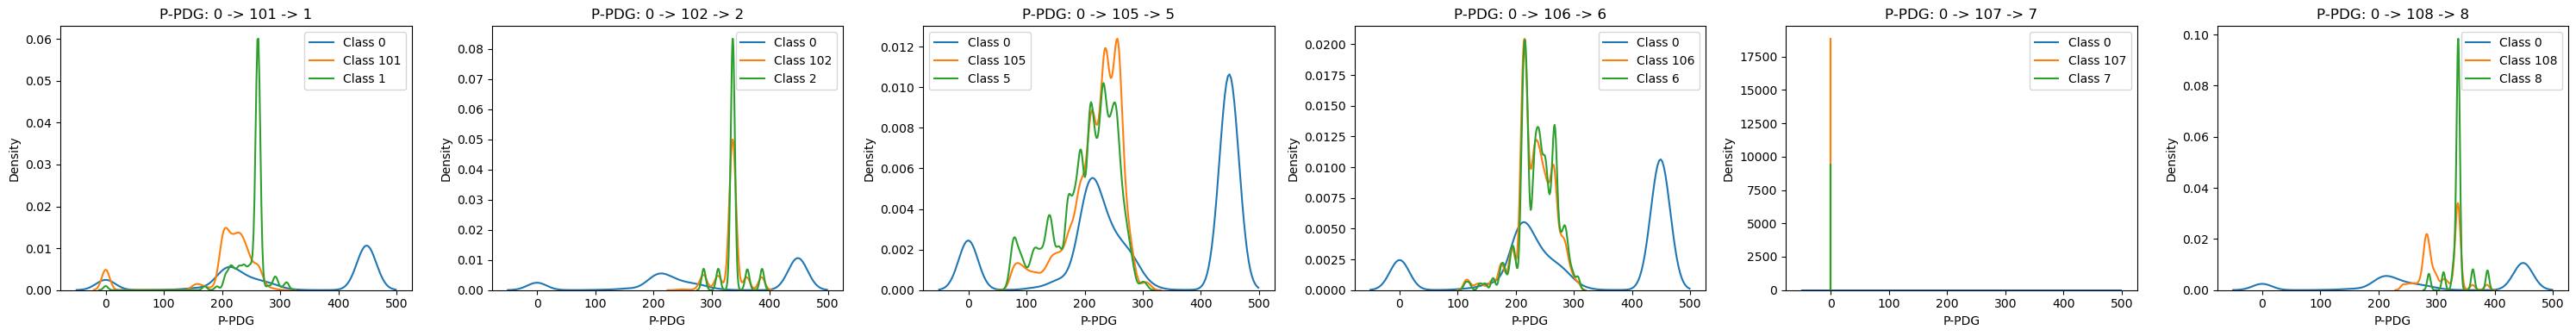

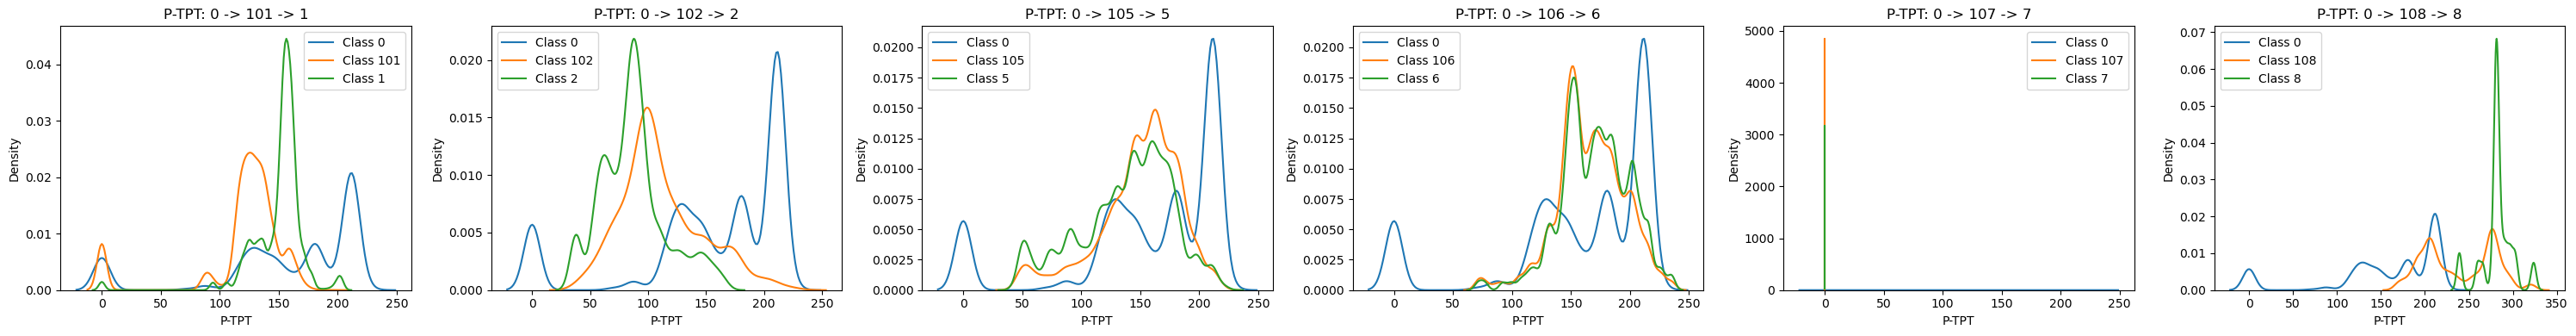

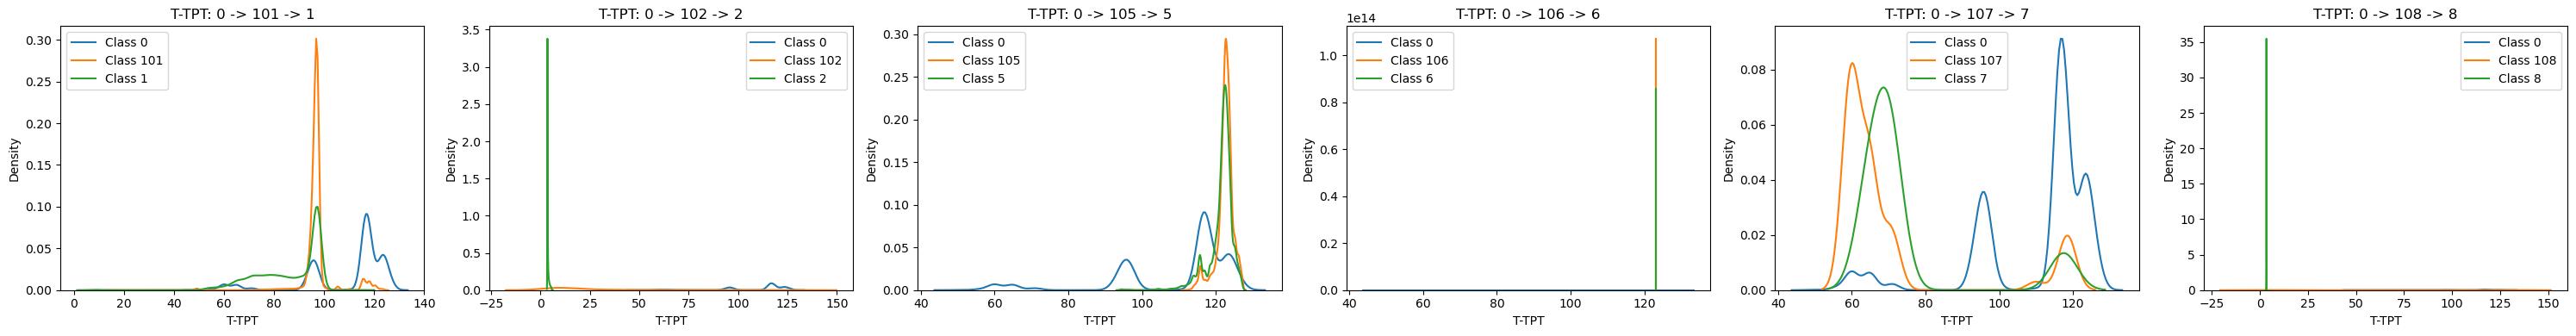

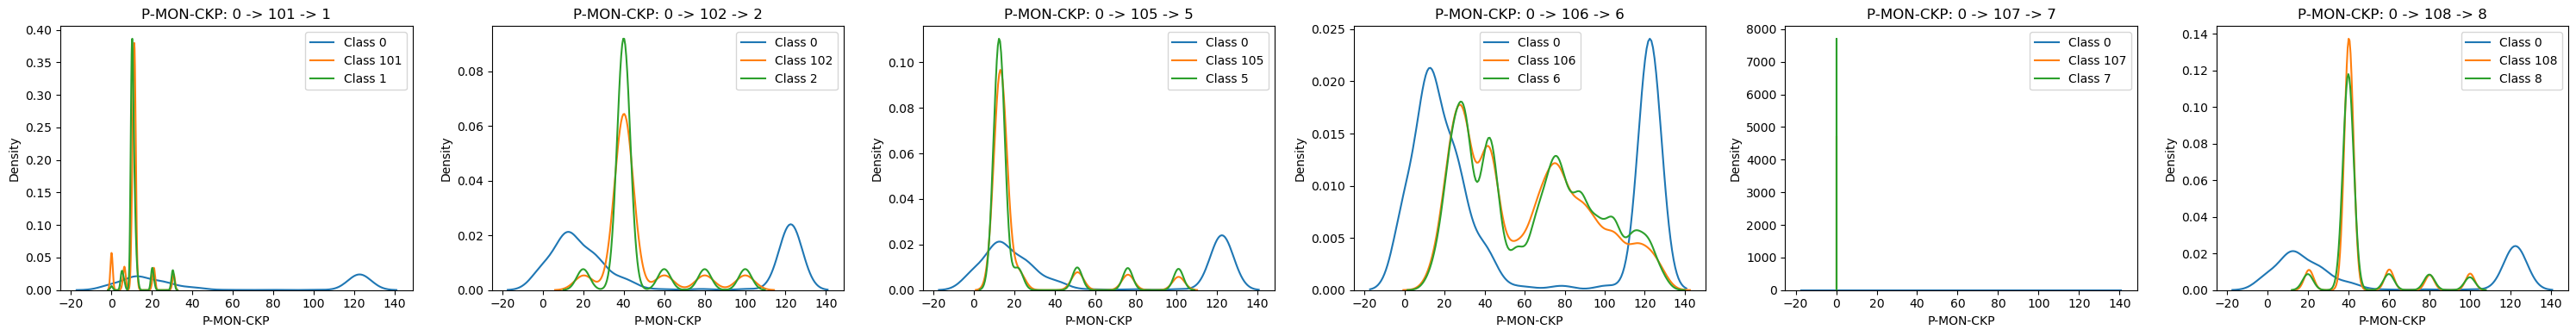

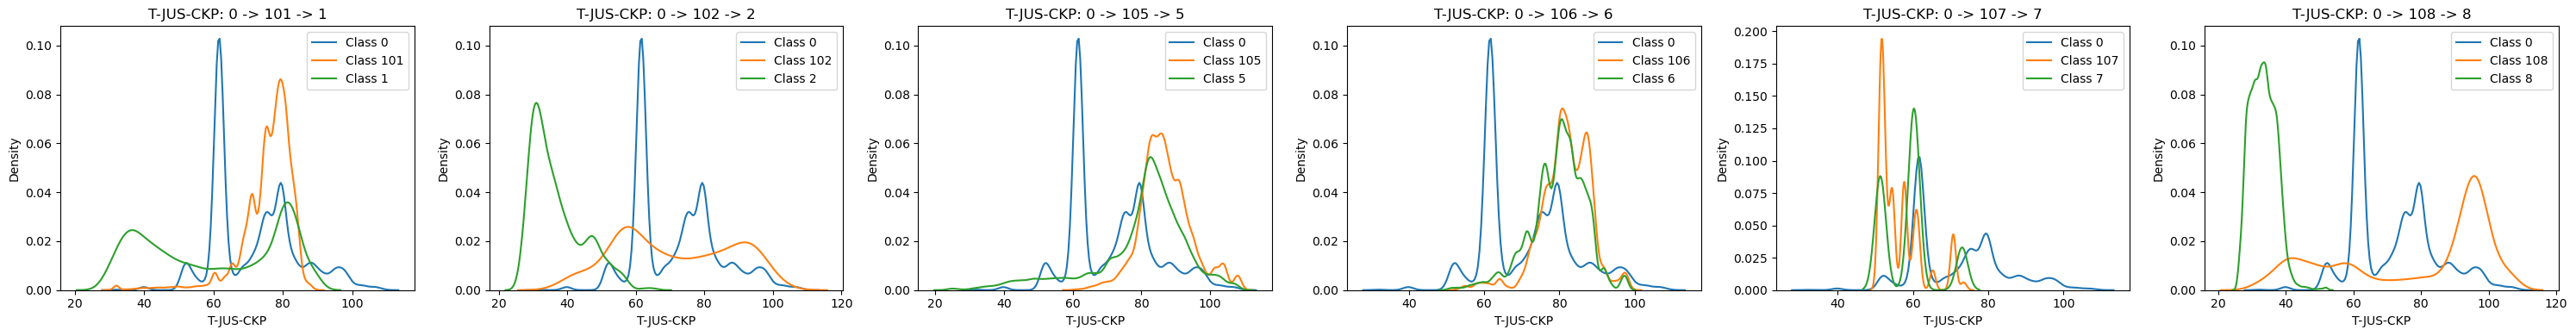

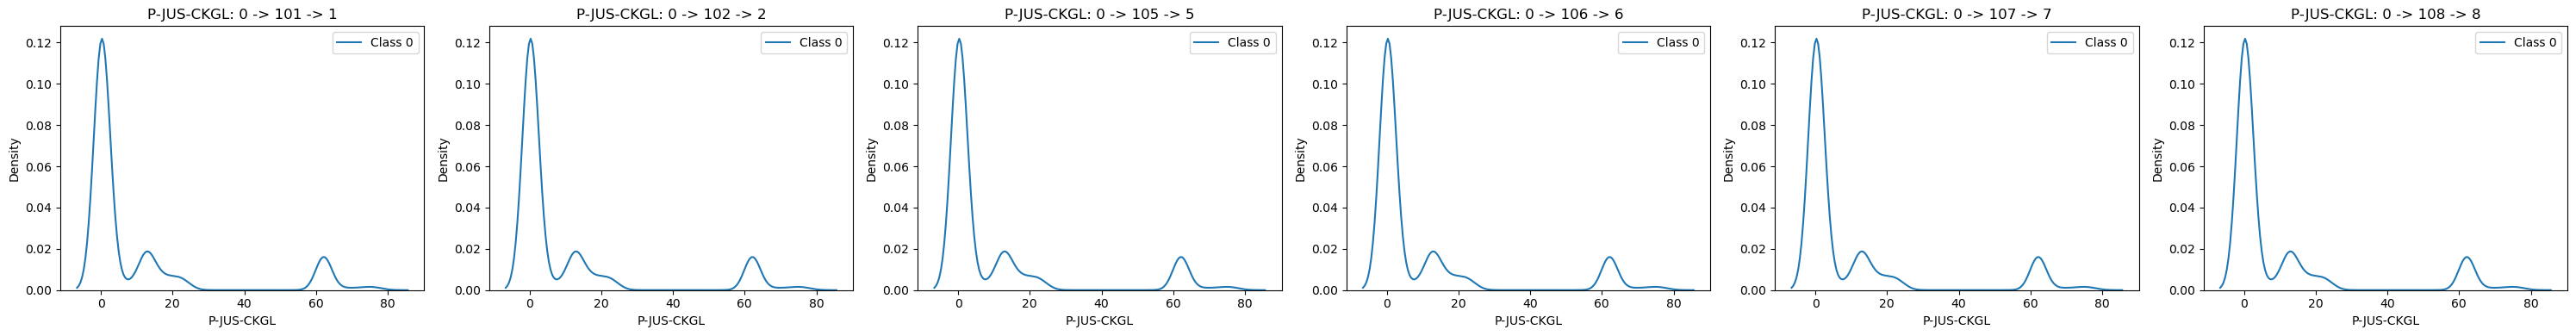

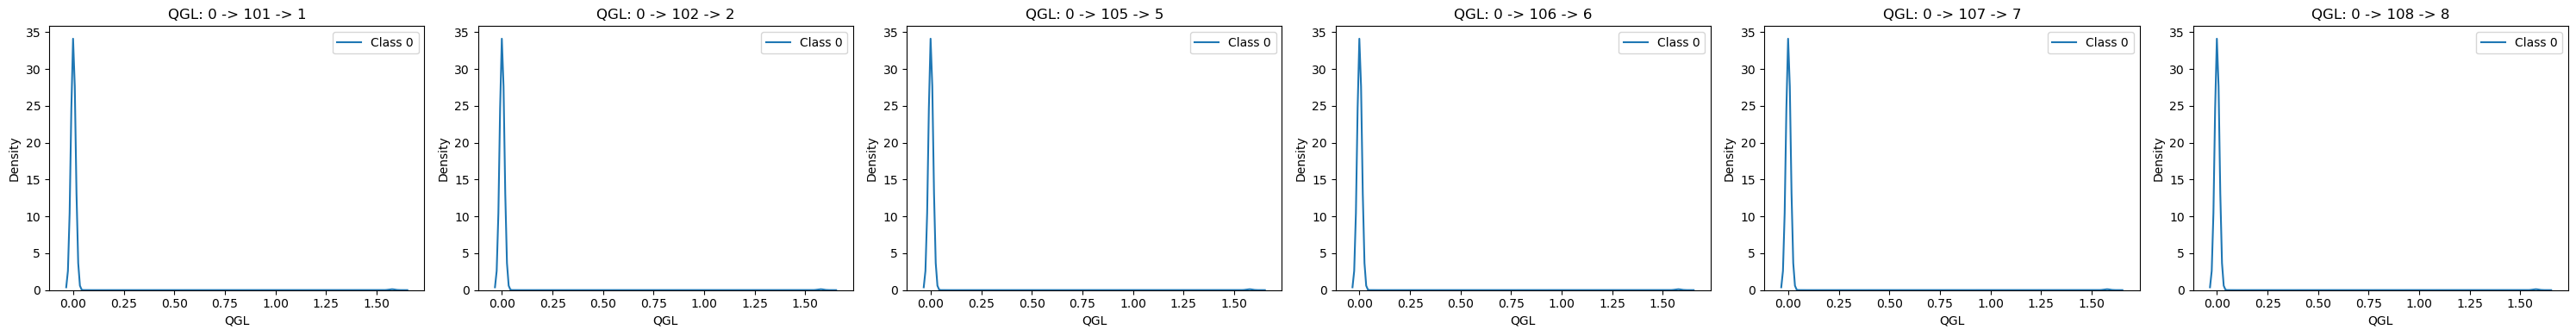

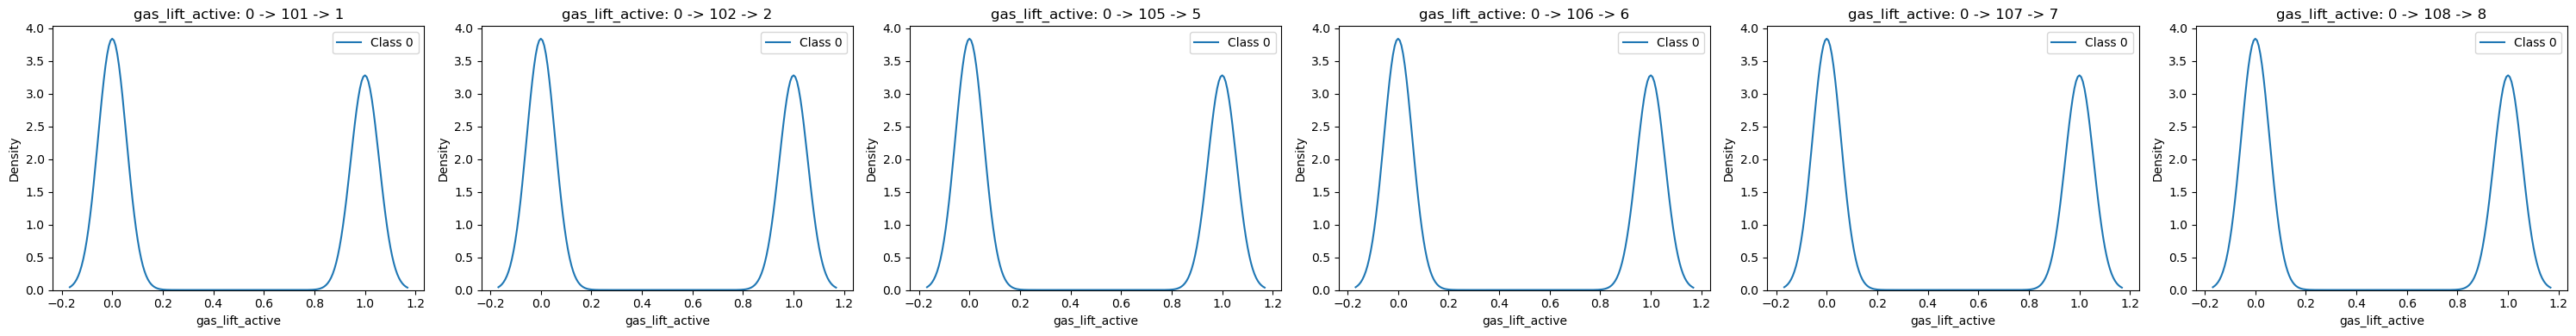

In [37]:
import seaborn as sns
# 1. Define Sensors and Detect Fault Families
columns = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL', 'gas_lift_active']
unique_classes = sorted(df['class'].unique())
fault_families = [(int(f), int(100 + f)) for f in unique_classes if 0 < f < 100 and (100 + f) in unique_classes]

# 2. Generate KDE plots per column
for col in columns:
    n_families = len(fault_families)
    fig, axes = plt.subplots(1, n_families, figsize=(5 * n_families, 4))
    
    # Ensure axes is iterable even if there's only one family
    if n_families == 1: axes = [axes]
    
    for idx, (fault, transient) in enumerate(fault_families):
        subset = df[df['class'].isin([0, fault, transient])]
        ax = axes[idx]
        
        # Plot Normal (0), then the Transient, then the Fault
        for c in [0, transient, fault]:
            sns.kdeplot(data=subset[subset['class'] == c], x=col, ax=ax, 
                        label=f'Class {int(c)}', warn_singular=False)
        
        ax.set_title(f"{col}: 0 -> {transient} -> {fault}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()